# Task 1 — Trend-Following Strategy

**BUSI97075-2526 | Applied Trading Strategies**

In [ ]:
%load_ext autoreload
%autoreload 2

import sys, os, warnings
from pathlib import Path
warnings.filterwarnings('ignore')

ROOT = Path(os.path.abspath('')).parents[1]
sys.path.insert(0, str(ROOT / 'tasks' / 'task_1'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.grid']  = True
plt.rcParams['grid.alpha'] = 0.25

from strategy_v2 import build_signals, run_strategy
from analytics   import (performance_stats, sector_contribution,
                          position_summary, plot_signals,
                          rolling_sharpe, plot_rolling_sharpe)

In [ ]:
prices = pd.read_csv(ROOT / 'data/training/close_prices_final.csv',
                     index_col=0, parse_dates=True).sort_index()

returns = prices.pct_change()
assets  = pd.read_csv(ROOT / 'data/raw/assets.csv')
factor  = returns.mean(axis=1)
factor.name = 'EW Factor'

print(f'Period      : {prices.index[0].date()} → {prices.index[-1].date()}')
print(f'Commodities : {prices.shape[1]}')
print(f'Days        : {len(prices):,}')
print(f'Price type  : actual futures closing prices (from Commodities Data xlsx)')

In [ ]:
# ── Layer 1 — Regime filter ────────────────────────────────────────────────────
FILTER_FAST    = 50      # SMA fast period
FILTER_SLOW    = 200     # SMA slow period
SLOPE_LOOKBACK = 100     # SMA slope window (days)

# ── Layer 2 — Entry timing ─────────────────────────────────────────────────────
EMA_WINDOW      = 14     # EMA cross window
RSI_WINDOW      = 14     # RSI period
RSI_LONG_LEVEL  = 50.0   # RSI must cross ABOVE this to confirm long
RSI_LEVEL       = 60.0   # RSI must cross BELOW this to confirm short
RSI_FLAG_WINDOW = 5      # days the RSI flag stays active after the break

# ── Slot manager — Exit conditions ─────────────────────────────────────────────
BB_WINDOW  = 100    # Bollinger Band period
BB_NUM_STD = 2.0    # Bollinger Band std multiplier
ATR_WINDOW = 50     # ATR lookback (50-day rolling mean abs return)
SL_MULT    = 3.0    # Stop Loss = entry_price × (1 ± SL_MULT × ATR_pct)

# ── Portfolio manager — sizing and risk ────────────────────────────────────────
RISK_PER_TRADE = 0.01    # capital fraction risked per trade (1%)
MAX_WEIGHT     = 0.20    # hard cap on individual position weight (20%)
LEVERAGE_CAP   = 2.50    # gross leverage cap (250%)

In [ ]:
positions, weights, port_r = run_strategy(
    prices,
    returns = returns,
    # Layer 1
    filter_fast    = FILTER_FAST,
    filter_slow    = FILTER_SLOW,
    slope_lookback = SLOPE_LOOKBACK,
    # Layer 2
    ema_window      = EMA_WINDOW,
    rsi_window      = RSI_WINDOW,
    rsi_long_level  = RSI_LONG_LEVEL,
    rsi_level       = RSI_LEVEL,
    rsi_flag_window = RSI_FLAG_WINDOW,
    # Slot manager — exits
    bb_window  = BB_WINDOW,
    bb_num_std = BB_NUM_STD,
    atr_window = ATR_WINDOW,
    sl_mult    = SL_MULT,
    # Portfolio manager — sizing
    risk_per_trade = RISK_PER_TRADE,
    max_weight     = MAX_WEIGHT,
    leverage_cap   = LEVERAGE_CAP,
)

### 1.0 Layer 1 — Regime Filter

In [65]:
from signals.signal_layer1_v2 import layer1_signal

# layer1_signal riceve l'intero DataFrame prices in una volta sola.
# Restituisce un NUOVO DataFrame (stessa shape, stesso indice, stesse colonne)
# con valori {-1, 0, +1, NaN} — non modifica prices.
l1 = layer1_signal(prices,
                   filter_fast    = FILTER_FAST,
                   filter_slow    = FILTER_SLOW,
                   slope_lookback = SLOPE_LOOKBACK)

# ── Struttura ──────────────────────────────────────────────────────────────────
print(f'prices : {prices.shape}   id={id(prices)}')
print(f'l1     : {l1.shape}   id={id(l1)}  ← oggetto separato, prices invariato')
print()
print(f'Valori in l1 : -1 (Short), 0 (Neutral), +1 (Long), NaN (warmup SMA{FILTER_SLOW})')
print()

# Le prime ~200 righe sono NaN perché SMA200 richiede 200 barre di storia
print('l1.head(3)  →  prime righe, ancora in warmup:')
display(l1.head(3))

print('l1.iloc[210:213]  →  dopo il warmup, segnali attivi:')
display(l1.iloc[210:213])

# ── Conteggio giorni per regime ────────────────────────────────────────────────
total = len(l1)
counts_df = pd.DataFrame({
    'Long (+1)'    : (l1 ==  1).sum(),
    'Neutral (0)'  : (l1 ==  0).sum(),
    'Short (-1)'   : (l1 == -1).sum(),
    'NaN (warmup)' : l1.isna().sum(),
    '% Long'       : ((l1 ==  1).sum() / total * 100).round(1),
    '% Neutral'    : ((l1 ==  0).sum() / total * 100).round(1),
    '% Short'      : ((l1 == -1).sum() / total * 100).round(1),
})
counts_df.index.name = 'Commodity'

print(f'\nConteggio su {total} giorni totali (NaN esclusi dal %):')
display(counts_df)

prices : (3715, 23)   id=4600129936
l1     : (3715, 23)   id=4682170928  ← oggetto separato, prices invariato

Valori in l1 : -1 (Short), 0 (Neutral), +1 (Long), NaN (warmup SMA200)

l1.head(3)  →  prime righe, ancora in warmup:


,LIVE CATTLE,LEAN HOGS,COFFEE 'C',CORN,COTTON NO.2,SOYBEAN,SUGAR #11,WHEAT FUTURE,BRENT CRUDE,COPPER FUTURE,...,SILVER,PLATINUM,WTI CRUDE,LME NICKEL,LME COPPER,LME ALUMINIUM,LME LEAD,LME ZINC,COCOA,HEATING OIL
Date,,,,,,,,,,,,,,,,,,,,,
2005-10-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005-10-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005-10-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


l1.iloc[210:213]  →  dopo il warmup, segnali attivi:


,LIVE CATTLE,LEAN HOGS,COFFEE 'C',CORN,COTTON NO.2,SOYBEAN,SUGAR #11,WHEAT FUTURE,BRENT CRUDE,COPPER FUTURE,...,SILVER,PLATINUM,WTI CRUDE,LME NICKEL,LME COPPER,LME ALUMINIUM,LME LEAD,LME ZINC,COCOA,HEATING OIL
Date,,,,,,,,,,,,,,,,,,,,,
2006-07-26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2006-07-27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2006-07-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Conteggio su 3715 giorni totali (NaN esclusi dal %):


,Long (+1),Neutral (0),Short (-1),NaN (warmup),% Long,% Neutral,% Short
Commodity,,,,,,,
LIVE CATTLE,1087,769,1600,259,29.3,20.7,43.1
LEAN HOGS,555,994,1907,259,14.9,26.8,51.3
COFFEE 'C',822,640,1994,259,22.1,17.2,53.7
CORN,785,674,1997,259,21.1,18.1,53.8
COTTON NO.2,1368,637,1451,259,36.8,17.1,39.1
SOYBEAN,1440,641,1375,259,38.8,17.3,37.0
SUGAR #11,704,734,2018,259,19.0,19.8,54.3
WHEAT FUTURE,753,530,2173,259,20.3,14.3,58.5
BRENT CRUDE,1729,671,1056,259,46.5,18.1,28.4


### 1.1 Layer 1 — Regime Accuracy Chart

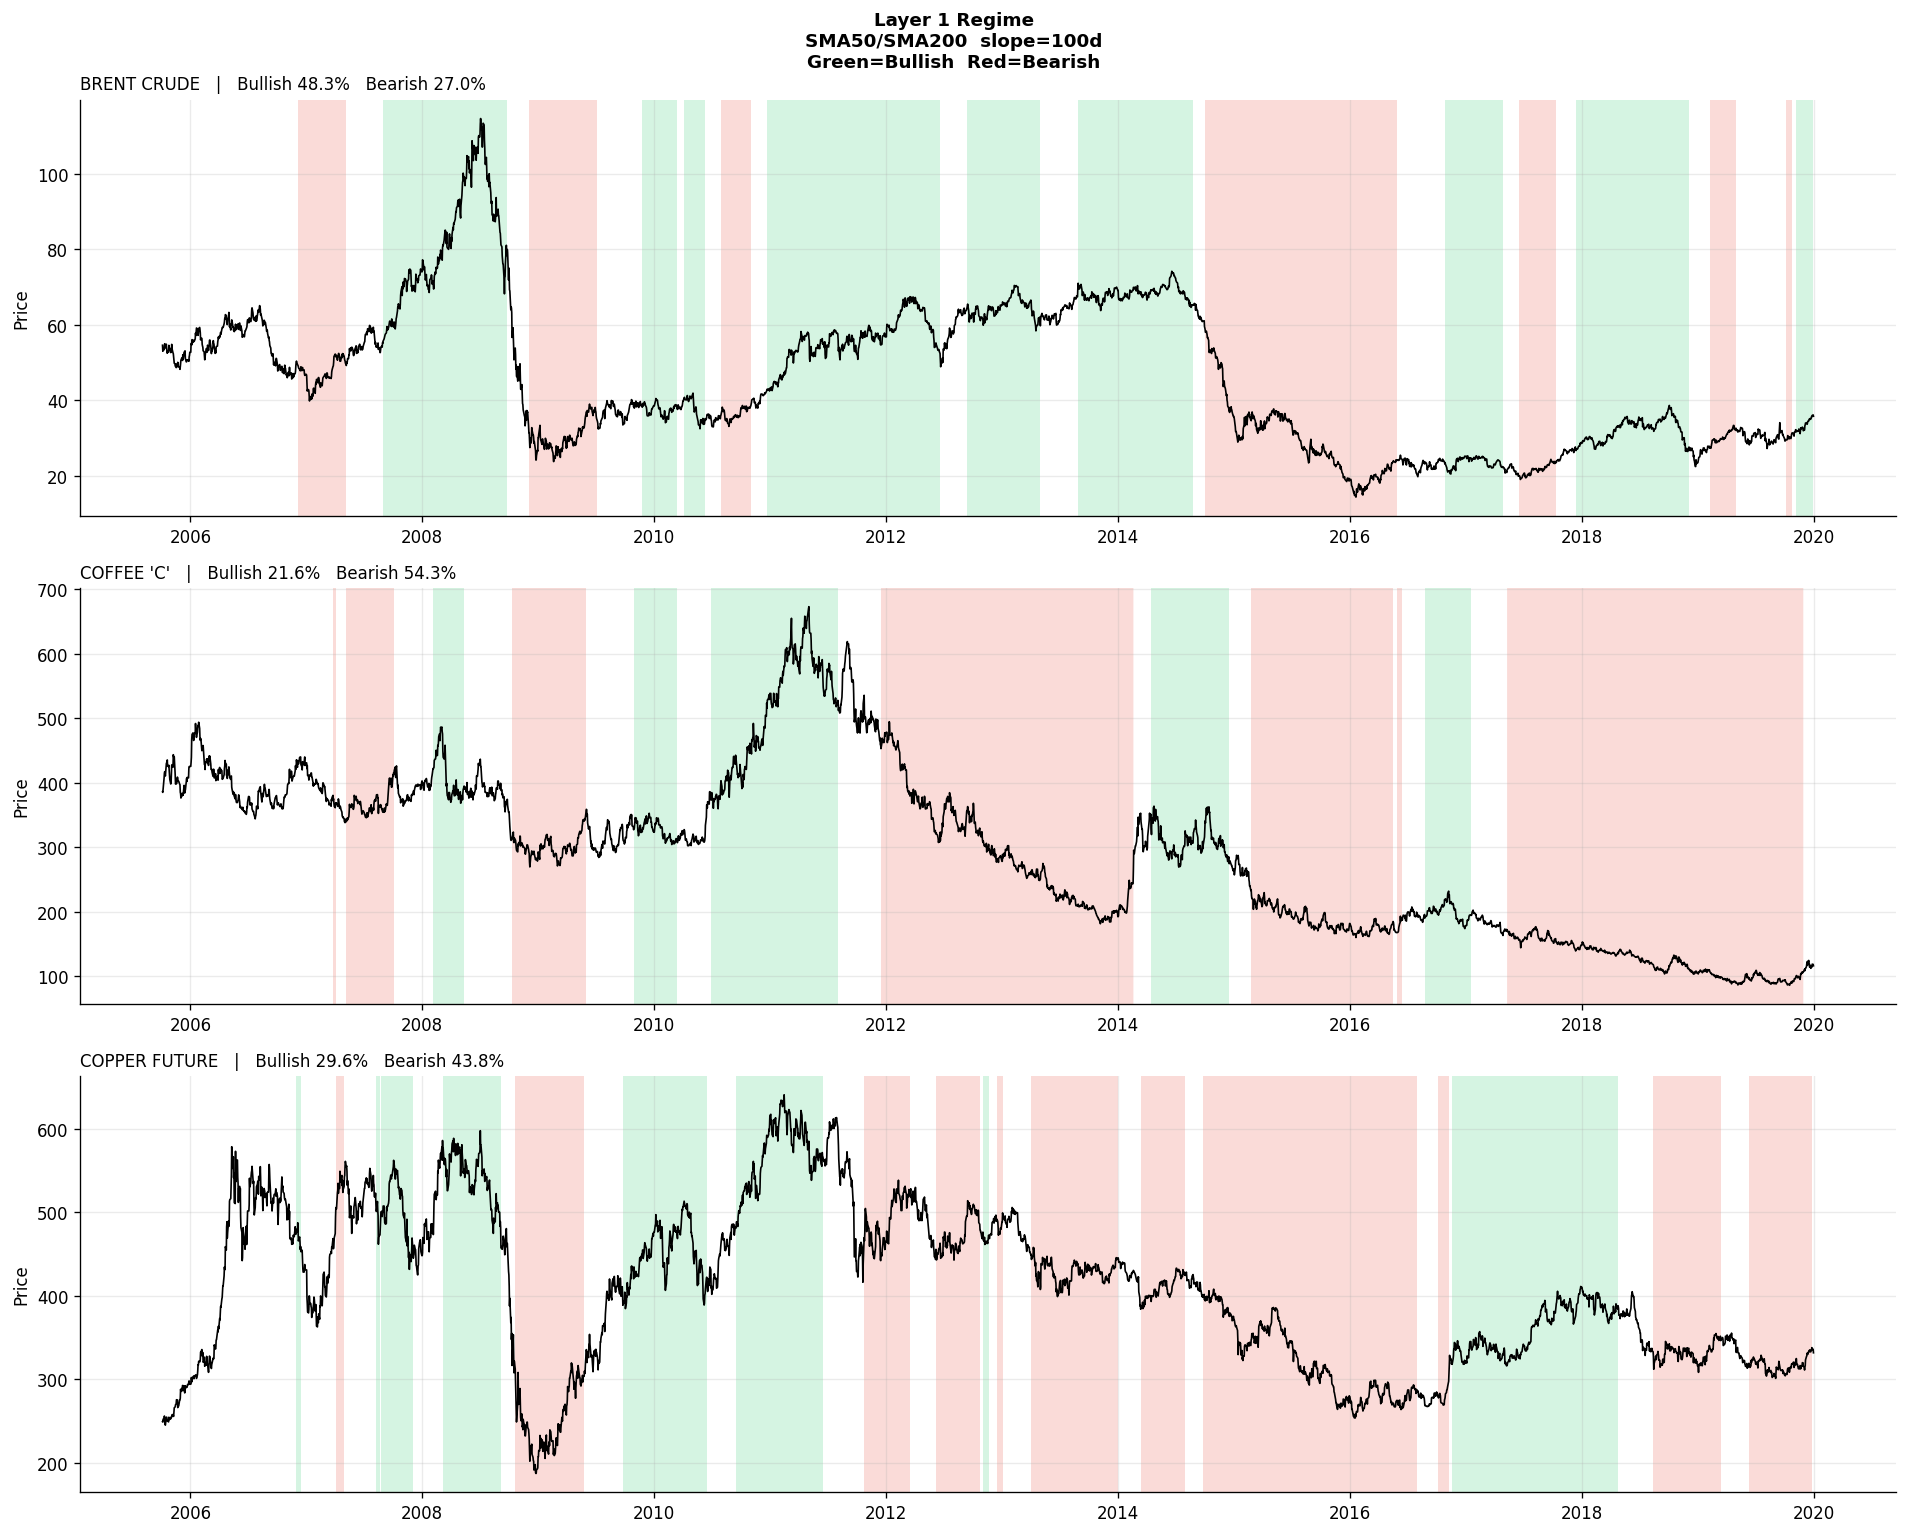

In [10]:
from signals.signal_layer1_v2 import layer1_signal
import matplotlib.patches as mpatches

l1 = layer1_signal(prices,
                   filter_fast    = FILTER_FAST,
                   filter_slow    = FILTER_SLOW,
                   slope_lookback = SLOPE_LOOKBACK)

REGIME_COMDTIES = ['BRENT CRUDE', "COFFEE 'C'", 'COPPER FUTURE']

fig, axes = plt.subplots(3, 1, figsize=(16, 13), sharex=False)
fig.suptitle(
    f'Layer 1 Regime\n'
    f'SMA{FILTER_FAST}/SMA{FILTER_SLOW}  slope={SLOPE_LOOKBACK}d\n'
    f'Green=Bullish  Red=Bearish',
    fontweight='bold', fontsize=11
)

for ax, col in zip(axes, REGIME_COMDTIES):
    p    = prices[col]
    sig1 = l1[col]

    ax.plot(p.index, p.values, color='black', lw=1.0, zorder=3)

    ax.fill_between(p.index, 0, 1,
                    where=(sig1 == 1),
                    transform=ax.get_xaxis_transform(),
                    color='#2ecc71', alpha=0.20, lw=0, zorder=1)
    ax.fill_between(p.index, 0, 1,
                    where=(sig1 == -1),
                    transform=ax.get_xaxis_transform(),
                    color='#e74c3c', alpha=0.20, lw=0, zorder=1)

    n_total  = sig1.notna().sum()
    pct_bull = (sig1 ==  1).sum() / n_total * 100
    pct_bear = (sig1 == -1).sum() / n_total * 100

    ax.set_title(
        f'{col}   |   Bullish {pct_bull:.1f}%   Bearish {pct_bear:.1f}%',
        fontsize=10, loc='left'
    )
    ax.set_ylabel('Price')
    ax.spines[['top', 'right']].set_visible(False)

fig.tight_layout()
plt.show()

### 2.0 Layer 2 — Entry Signal Accuracy Chart

Green = Bullish regime (+1) | Red = Bearish regime (−1) | White = Neutral / warmup

Layer 2 entry signals — head(5):


,LIVE CATTLE,LEAN HOGS,COFFEE 'C',CORN,COTTON NO.2,SOYBEAN,SUGAR #11,WHEAT FUTURE,BRENT CRUDE,COPPER FUTURE,...,SILVER,PLATINUM,WTI CRUDE,LME NICKEL,LME COPPER,LME ALUMINIUM,LME LEAD,LME ZINC,COCOA,HEATING OIL
Date,,,,,,,,,,,,,,,,,,,,,
2005-10-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005-10-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005-10-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005-10-10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005-10-11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Layer 2 entry signal counts per commodity:


,Long (+1),Short (-1),Total
Commodity,,,
LIVE CATTLE,37,31,68
LEAN HOGS,12,44,56
COFFEE 'C',33,37,70
CORN,23,39,62
COTTON NO.2,56,29,85
SOYBEAN,49,31,80
SUGAR #11,27,46,73
WHEAT FUTURE,24,46,70
BRENT CRUDE,70,27,97


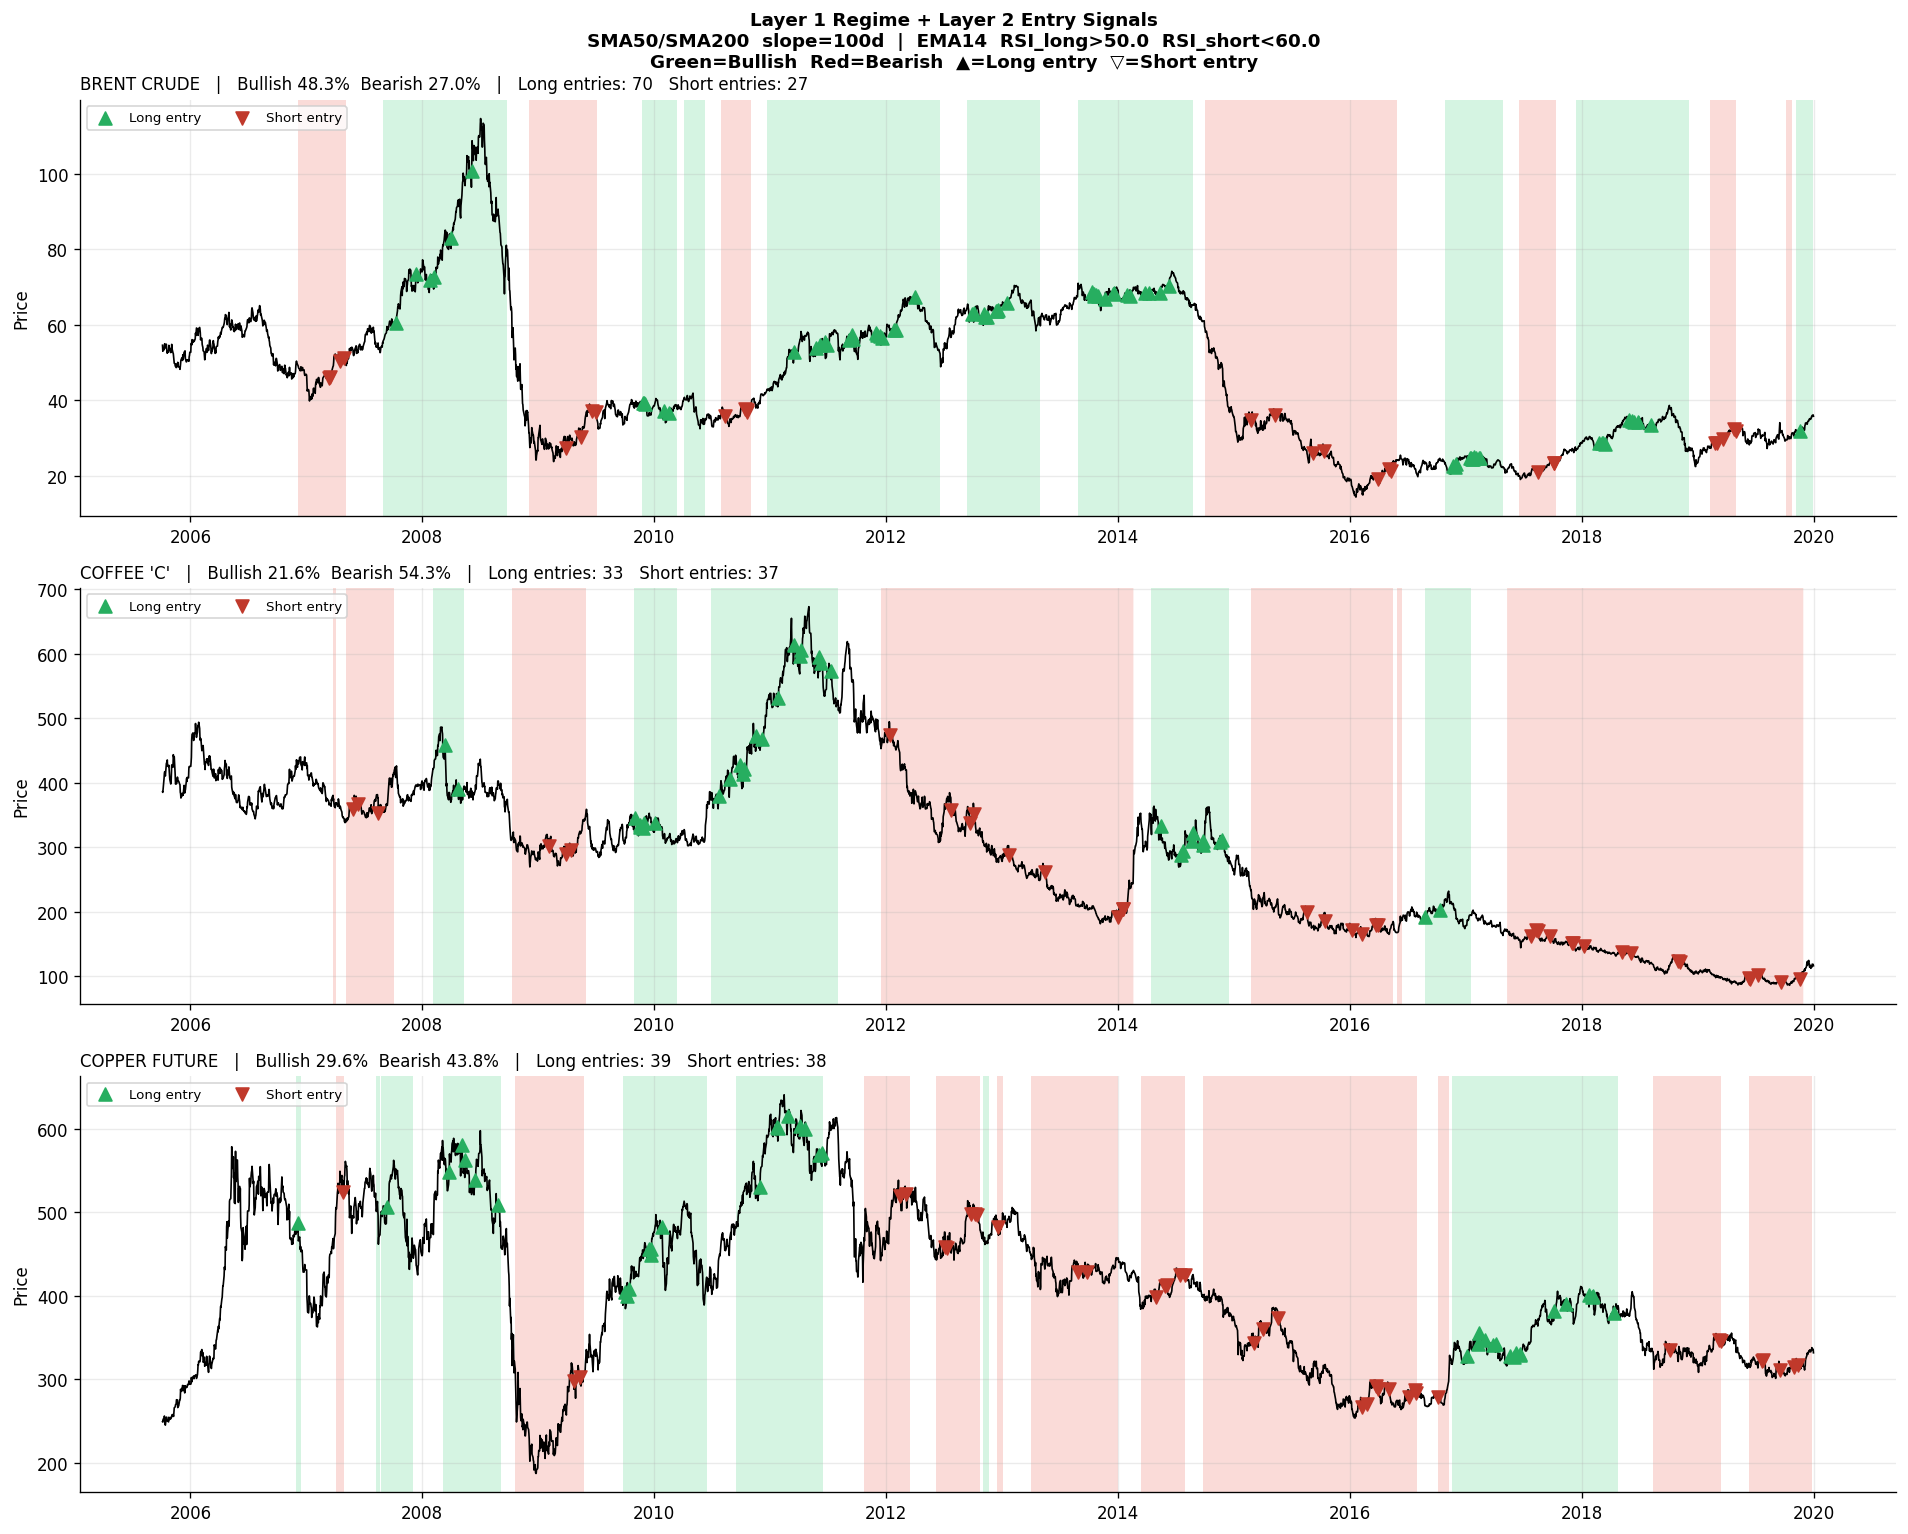

In [11]:
from signals.signal_layer1_v2 import layer1_signal
from signals.signal_layer2_v2 import layer2_signal
import matplotlib.patches as mpatches

l1 = layer1_signal(prices,
                   filter_fast    = FILTER_FAST,
                   filter_slow    = FILTER_SLOW,
                   slope_lookback = SLOPE_LOOKBACK)

l2 = layer2_signal(prices, layer1=l1,
                   ema_window      = EMA_WINDOW,
                   rsi_window      = RSI_WINDOW,
                   rsi_long_level  = RSI_LONG_LEVEL,
                   rsi_level       = RSI_LEVEL,
                   rsi_flag_window = RSI_FLAG_WINDOW)

# ── L2 structure ───────────────────────────────────────────────────────────────
print('Layer 2 entry signals — head(5):')
display(l2.head())

# ── Signal count table ─────────────────────────────────────────────────────────
sig_table = pd.DataFrame({
    'Long  (+1)' : (l2 ==  1).sum(),
    'Short (-1)' : (l2 == -1).sum(),
    'Total'      : ((l2 == 1) | (l2 == -1)).sum(),
})
sig_table.index.name = 'Commodity'
print('\nLayer 2 entry signal counts per commodity:')
display(sig_table)

# ── Regime + entry marker chart ────────────────────────────────────────────────
REGIME_COMDTIES = ['BRENT CRUDE', "COFFEE 'C'", 'COPPER FUTURE']

fig, axes = plt.subplots(3, 1, figsize=(16, 13), sharex=False)
fig.suptitle(
    f'Layer 1 Regime + Layer 2 Entry Signals\n'
    f'SMA{FILTER_FAST}/SMA{FILTER_SLOW}  slope={SLOPE_LOOKBACK}d  |  EMA{EMA_WINDOW}  RSI_long>{RSI_LONG_LEVEL}  RSI_short<{RSI_LEVEL}\n'
    f'Green=Bullish  Red=Bearish  ▲=Long entry  ▽=Short entry',
    fontweight='bold', fontsize=11
)

for ax, col in zip(axes, REGIME_COMDTIES):
    p    = prices[col]
    sig1 = l1[col]
    sig2 = l2[col]

    # Price line
    ax.plot(p.index, p.values, color='black', lw=1.0, zorder=3)

    # Regime shading
    ax.fill_between(p.index, 0, 1,
                    where=(sig1 == 1),
                    transform=ax.get_xaxis_transform(),
                    color='#2ecc71', alpha=0.20, lw=0, zorder=1)
    ax.fill_between(p.index, 0, 1,
                    where=(sig1 == -1),
                    transform=ax.get_xaxis_transform(),
                    color='#e74c3c', alpha=0.20, lw=0, zorder=1)

    # Layer 2 entry markers
    long_days  = sig2[sig2 ==  1].index
    short_days = sig2[sig2 == -1].index

    ax.scatter(long_days,  p.loc[long_days],
               marker='^', color='#27ae60', s=60, zorder=5, label='Long entry')
    ax.scatter(short_days, p.loc[short_days],
               marker='v', color='#c0392b', s=60, zorder=5, label='Short entry')

    n_total  = sig1.notna().sum()
    pct_bull = (sig1 ==  1).sum() / n_total * 100
    pct_bear = (sig1 == -1).sum() / n_total * 100

    ax.set_title(
        f'{col}   |   Bullish {pct_bull:.1f}%  Bearish {pct_bear:.1f}%   |   '
        f'Long entries: {len(long_days)}   Short entries: {len(short_days)}',
        fontsize=10, loc='left'
    )
    ax.set_ylabel('Price')
    ax.legend(fontsize=8, loc='upper left', ncol=2)
    ax.spines[['top', 'right']].set_visible(False)

fig.tight_layout()
plt.show()

#### Regime Identification:

The Layer 1 regime filter demonstrates reasonable stability and captures the major directional cycles across all three commodities with good accuracy. Notable examples include the sustained bullish regime on Brent Crude during the 2006–2008 commodity supercycle, the sharp bearish transition following the 2008 financial crisis, the recovery into a bullish regime through 2009–2013, and the extended bearish regime from 2014 onwards as energy markets entered a prolonged downturn. On Coffee and Copper, the filter correctly identifies the multi-year bearish cycle from 2011–2019, remaining in a short regime through the structural decline without excessive switching.

While the regime identification is broadly effective, a potential enhancement would be the incorporation of cross-asset signals — such as the US Dollar Index, commodity-specific fundamental indicators, or sector-level momentum — to further validate regime transitions and reduce the risk of premature or false regime switches in ambiguous market environments.

#### Entry Signal Quality:
The entry signals continue to exhibit clustering in several instances, with multiple long or short signals firing in close proximity. Within the slot manager this is partially mitigated, as the single-position constraint causes subsequent signals to be ignored while a position is already open, effectively reducing redundant entries as will be demonstrated in the backtesting analysis.

However, a more fundamental issue persists — entry signals frequently trigger at or near reversal points, capturing the tail end of a move rather than the beginning of a new trend. While the RSI filter has reduced the frequency of false signals, it is insufficient on its own to systematically distinguish between genuine trend initiations and short-lived momentum spikes, particularly in the absence of volume data.

### 0.1 Position Grid Analysis

Blue = Long, Red = Short, White = Flat

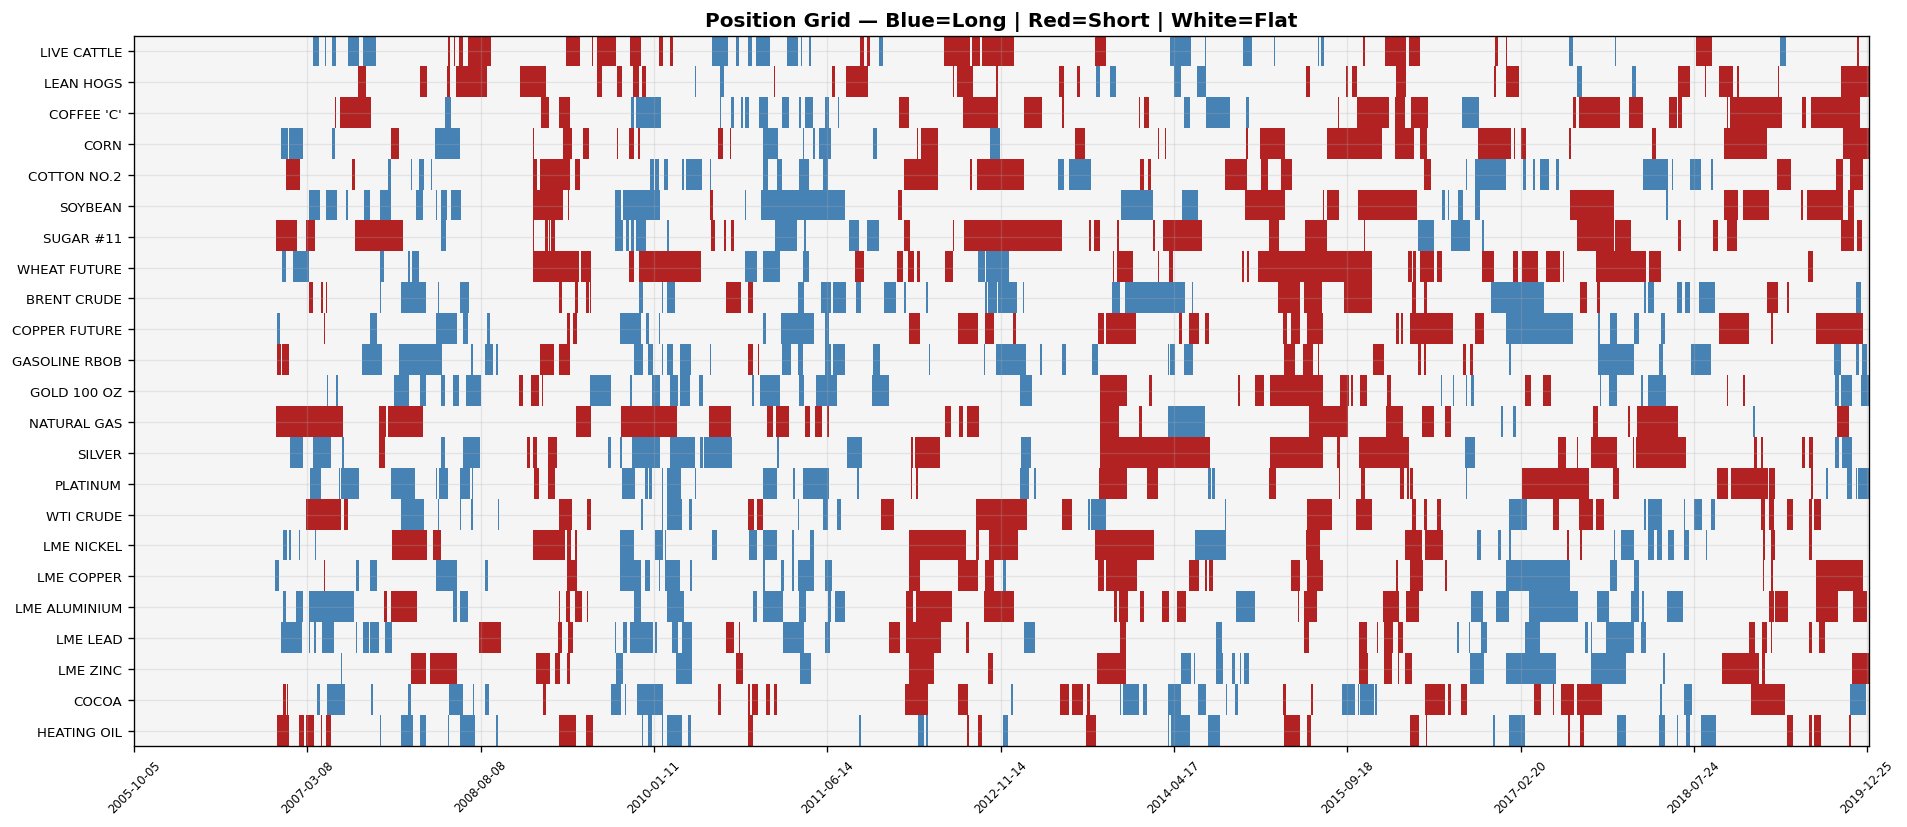

               Days Long  Days Short  Days Flat  % Long  % Short
LIVE CATTLE          295         478       2942     7.9     12.9
LEAN HOGS             84         520       3111     2.3     14.0
COFFEE 'C'           275         762       2678     7.4     20.5
CORN                 195         623       2897     5.2     16.8
COTTON NO.2          391         486       2838    10.5     13.1
SOYBEAN              554         593       2568    14.9     16.0
SUGAR #11            241         795       2679     6.5     21.4
WHEAT FUTURE         211         934       2570     5.7     25.1
BRENT CRUDE          619         296       2800    16.7      8.0
COPPER FUTURE        406         584       2725    10.9     15.7
GASOLINE RBOB        607         184       2924    16.3      5.0
GOLD 100 OZ          509         311       2895    13.7      8.4
NATURAL GAS           95         886       2734     2.6     23.8
SILVER               414         775       2526    11.1     20.9
PLATINUM             409 

In [12]:
import matplotlib.colors as mcolors

cmap  = mcolors.ListedColormap(['firebrick', 'whitesmoke', 'steelblue'])
norm  = mcolors.BoundaryNorm([-1.5, -0.5, 0.5, 1.5], cmap.N)
step  = max(1, len(positions) // 10)

fig, ax = plt.subplots(figsize=(16, 7))
ax.imshow(positions.T.values, aspect='auto', cmap=cmap, norm=norm, interpolation='none')
ax.set_yticks(range(len(positions.columns)))
ax.set_yticklabels(positions.columns, fontsize=8)
ax.set_xticks(range(0, len(positions), step))
ax.set_xticklabels([str(d.date()) for d in positions.index[::step]], rotation=45, fontsize=7)
ax.set_title('Position Grid — Blue=Long | Red=Short | White=Flat', fontweight='bold')
fig.tight_layout()
plt.show()

print(position_summary(positions))

**Position Grid Analysis**

**Positives:**
The grid shows reasonable diversification across commodities, with positions not systematically concentrated in the same direction at any given time. Flat periods are present, indicating the system correctly identifies when conditions do not warrant exposure. The 2007–2008 commodity supercycle and the 2014–2016 bear market in energy and metals appear to be partially captured.

**Concerns:**
The primary issue is trade duration — the majority of positions appear to last only a few days, which is inconsistent with the expected behaviour of a trend-following CTA strategy, where holding periods should typically range from several weeks to months. The rapid alternation between long and short on several commodities, notably Cocoa and Heating Oil, suggests the system is not successfully latching onto sustained directional moves. The absence of extended single-colour bars across the grid indicates that trades are being closed prematurely before the underlying trend has fully developed, compounded by entries that are frequently late, capturing reversals rather than the core of the trend.

**Likely Root Causes:**
The stop loss, currently approximated from closing prices only, may be too tight relative to the typical noise level of these markets, causing positions to be stopped out by short-lived volatility spikes rather than genuine trend reversals. A possible enhancement would be to replace the ATR approximation with EWMA volatility, which may better characterise the true volatility profile of each asset and provide a more stable basis for holding positions through a trend.

A secondary cause may be the susceptibility of the EMA14 crossover to false breakouts. Although it represents a better compromise than EMA20 (too slow), and the slot manager's single-position constraint already reduces signal clustering in line with CTA philosophy, the absence of volume data makes it difficult to produce sufficiently precise entry signals from price alone. A potential enhancement would be to redesign Layer 2 using Bollinger Band expansion and contraction to generate cleaner signals without reliance on volume.

**Next Step:**
Prior to implementing the above enhancements, key backtesting metrics will be produced to establish a quantitative baseline.

### 0.2 Entry / Exit Timing Check

Verify: layer2 signal fires at t, position opens at t, weight non-zero at t+1 (exec_lag=1).

In [ ]:
DIAG_COMDTY = 'BRENT CRUDE'

signals = build_signals(prices,
    filter_fast=FILTER_FAST, filter_slow=FILTER_SLOW, slope_lookback=SLOPE_LOOKBACK,
    ema_window=EMA_WINDOW, rsi_window=RSI_WINDOW,
    rsi_long_level=RSI_LONG_LEVEL, rsi_level=RSI_LEVEL,
    rsi_flag_window=RSI_FLAG_WINDOW,
)

# pick the first 3 long entries for the selected commodity
entry_days      = signals['layer2'][DIAG_COMDTY]
entry_long_days = entry_days[entry_days == 1].index[:3]

diag_rows = []
for t in entry_long_days:
    t1 = prices.index[prices.index.get_loc(t) + 1]   # t+1
    diag_rows.append({
        'entry_signal_day (t)' : t.date(),
        'layer2[t]'            : signals['layer2'].loc[t, DIAG_COMDTY],
        'position[t]'          : positions.loc[t, DIAG_COMDTY],
        'price[t]'             : round(prices.loc[t, DIAG_COMDTY], 2),
        'weight[t+1]'          : round(weights.loc[t1, DIAG_COMDTY], 4),
        'price[t+1]'           : round(prices.loc[t1, DIAG_COMDTY], 2),
    })

pd.DataFrame(diag_rows).set_index('entry_signal_day (t)')

## ATR(50) Investigation — Stop Distance per Commodity

In [ ]:
from indicators import atr_pct

# ── ATR(50) rolling — percentuale del prezzo ───────────────────────────────────
# ATR_pct = media mobile (50gg) delle variazioni assolute giornaliere / prezzo
# Rappresenta la volatilità giornaliera tipica come % del prezzo.
# Lo stop SAR iniziale = SAR_INITIAL_MULT × ATR_pct dal prezzo di entrata.

atr50 = atr_pct(prices, window=50)

# ── Media annuale ATR(50) per ogni commodity ───────────────────────────────────
atr_annual = (
    atr50
    .groupby(atr50.index.year)
    .mean()
    .mul(100)          # → percentuale
    .round(3)
)
atr_annual.index.name = 'Year'

print('=== ATR(50) medio annuale per commodity (% del prezzo) ===')
print('Lettura: un valore di 1.5 significa che la mossa giornaliera tipica')
print('         è ~1.5% del prezzo. Con SAR_INITIAL_MULT=3.5 lo stop')
print('         iniziale sarebbe 3.5 × 1.5% = 5.25% dal prezzo di entrata.\n')
display(atr_annual)

# ── Media sull'intero campione per commodity ───────────────────────────────────
atr_mean = atr50.mean().mul(100).round(3).sort_values(ascending=False)
atr_mean.name = 'ATR(50) medio % (intero campione)'

print('\n=== Ranking ATR medio — intero campione 2005-2019 ===')
print('(più alto = più volatile = stop più lontano per stesso moltiplicatore)\n')
for commodity, val in atr_mean.items():
    stop_35 = val * 3.5
    stop_60 = val * 6.0
    bar = '█' * int(val * 30)
    print(f'  {commodity:<22} ATR={val:.3f}%   '
          f'stop@3.5x={stop_35:.2f}%   stop@6.0x={stop_60:.2f}%   {bar}')

# ── Heatmap ATR annuale ────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

fig, ax = plt.subplots(figsize=(16, 7))
im = ax.imshow(atr_annual.T.values, aspect='auto', cmap='YlOrRd')

ax.set_xticks(range(len(atr_annual.index)))
ax.set_xticklabels(atr_annual.index, fontsize=9)
ax.set_yticks(range(len(atr_annual.columns)))
ax.set_yticklabels(atr_annual.columns, fontsize=8)

for i in range(len(atr_annual.columns)):
    for j in range(len(atr_annual.index)):
        val = atr_annual.iloc[j, i]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=6.5, color='black' if val < 2.5 else 'white')

plt.colorbar(im, ax=ax, label='ATR(50) % del prezzo')
ax.set_title('ATR(50) medio annuale per commodity  (% del prezzo)',
             fontweight='bold', fontsize=12)
fig.tight_layout()
plt.show()

### 0.3 Stop Loss Check

For the first long trade on the selected commodity: verify the SL is placed correctly below the entry price (fixed at `SL_MULT × ATR_pct`) and that the trade exits at SL or upper BB.

In [ ]:
from indicators import atr_pct, bollinger_bands

# find first complete long trade (entry → exit) for DIAG_COMDTY
pos_col  = positions[DIAG_COMDTY]
in_long  = (pos_col == 1)
entries  = in_long & (pos_col.shift(1) != 1)
exits    = (pos_col == 0) & (pos_col.shift(1) == 1)

first_entry = entries[entries].index[0]
later_exits = exits[exits & (exits.index > first_entry)]

if len(later_exits) == 0:
    print("No completed long trade found — position still open.")
else:
    first_exit = later_exits.index[0]
    trade_idx  = prices.index[
        (prices.index >= first_entry) & (prices.index <= first_exit + pd.Timedelta(days=3))
    ]

    p_trade  = prices.loc[trade_idx, DIAG_COMDTY]
    _, ub, _ = bollinger_bands(prices, BB_WINDOW, BB_NUM_STD)
    ub_trade = ub.loc[trade_idx, DIAG_COMDTY]

    # Fixed SL: computed once at entry from ATR, never moves
    entry_price = prices.loc[first_entry, DIAG_COMDTY]
    entry_atr   = atr_pct(prices, ATR_WINDOW).loc[first_entry, DIAG_COMDTY]
    sl_level    = entry_price * (1.0 - SL_MULT * entry_atr)

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(p_trade.index,  p_trade.values,  color='black',     lw=1.5, label='Price')
    ax.axhline(sl_level, color='firebrick', lw=1.5, linestyle='--',
               label=f'Stop Loss  ({SL_MULT}×ATR = {((entry_price - sl_level)/entry_price*100):.1f}% below entry)')
    ax.plot(ub_trade.index, ub_trade.values, color='steelblue', lw=1.2, linestyle=':',
            label=f'Upper BB({BB_WINDOW})')
    ax.axvline(first_entry, color='green',     lw=1.2, linestyle='--', label=f'Entry  {first_entry.date()}')
    ax.axvline(first_exit,  color='firebrick', lw=1.2, linestyle='--', label=f'Exit   {first_exit.date()}')
    ax.set_title(f'{DIAG_COMDTY} — First Long Trade | Stop Loss Check', fontweight='bold')
    ax.legend(fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)
    fig.tight_layout()
    plt.show()

    print(f"Entry : {first_entry.date()}  price={entry_price:.2f}  ATR={entry_atr*100:.2f}%")
    print(f"SL    : {sl_level:.2f}  (distance={(entry_price - sl_level)/entry_price*100:.1f}%  =  {SL_MULT}×ATR)")
    print(f"Exit  : {first_exit.date()}   price={prices.loc[first_exit, DIAG_COMDTY]:.2f}")

### 0.4 Weights Normalisation Check

`sum(|w|)` should equal 1 at all times when any position is active.

In [ ]:
gross = weights.abs().sum(axis=1)
active = gross[gross > 0]

print(f"Gross exposure (active days only):")
print(f"  min  = {active.min():.4f}")
print(f"  max  = {active.max():.4f}")
print(f"  mean = {active.mean():.4f}")
print(f"  Days with no position: {(gross == 0).sum()}")

fig, ax = plt.subplots(figsize=(13, 3))
gross.plot(ax=ax, lw=0.8, color='steelblue')
ax.axhline(1.0, color='black', lw=0.8, linestyle='--', label='Target = 1')
ax.set_title('Gross Exposure over Time  (should be 1 when positions active)', fontweight='bold')
ax.set_ylabel('sum(|w|)')
ax.legend(fontsize=9)
ax.spines[['top','right']].set_visible(False)
fig.tight_layout()
plt.show()

## 1. Performance

In [14]:
stats = pd.concat([
    performance_stats(port_r, label='Trend Strategy v2',
                      factor=factor, weights=weights, positions=positions),
    performance_stats(factor.reindex(port_r.index).dropna(), label='EW Factor'),
], axis=1).T

stats

,Ann. Return %,Ann. Vol %,Sharpe,Sortino,Calmar,Max DD %,Skewness,Hit Rate,Num Trades,Trades / Year,Ann. Turnover %,Alpha (ann) %,Beta,R²
Trend Strategy v2,1.78,15.98,0.111,0.139,0.040,-44.36,-0.434,0.456,955.0,64.8,1230.9,1.87,-0.074,0.005
EW Factor,1.23,15.65,0.078,0.106,0.023,-52.91,-0.217,0.508,NaN,NaN,NaN,NaN,NaN,NaN


### Sharpe Robustness — Rolling 1-Year Window

A consistently positive rolling Sharpe confirms the strategy is not driven by a single lucky period.

In [ ]:
plot_rolling_sharpe(
    {'Trend Strategy v2': port_r, 'EW Factor': factor.reindex(port_r.index)},
    window=252,
)

## 2. Cumulative Returns

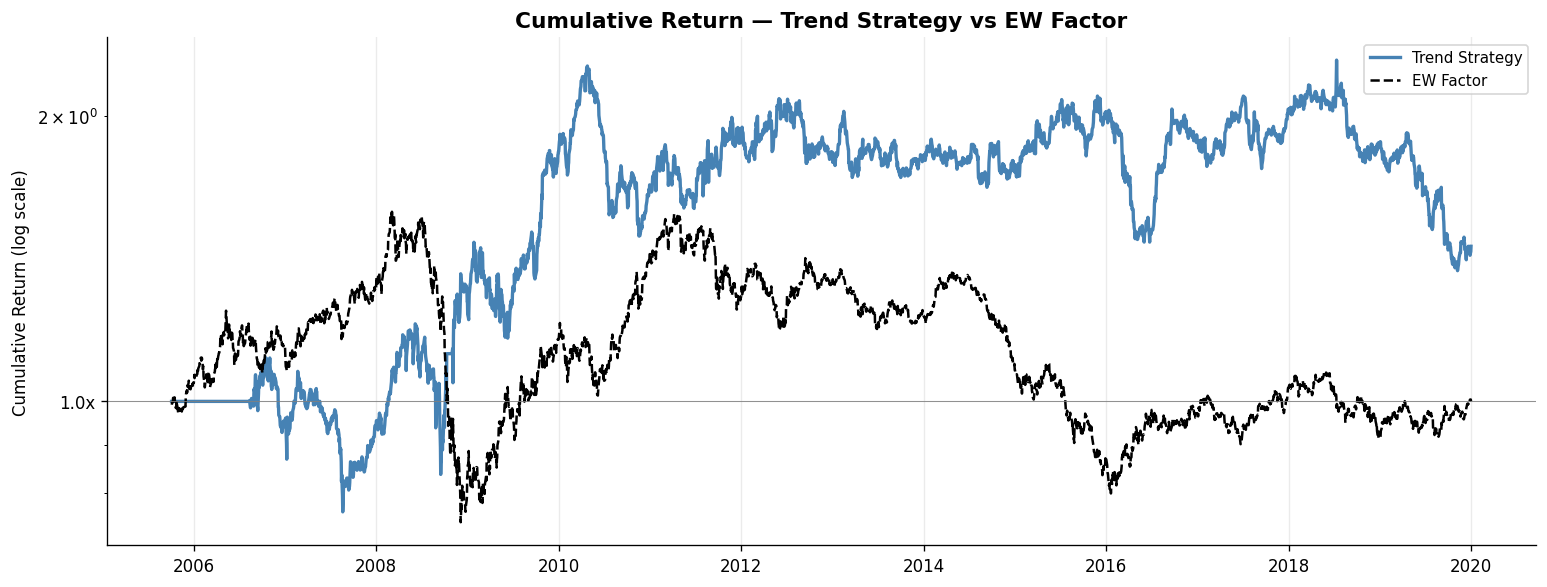

In [37]:
cum_strat  = (1 + port_r.dropna()).cumprod()
cum_factor = (1 + factor.reindex(port_r.index).dropna()).cumprod()

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(cum_strat.index,  cum_strat.values,  color='steelblue', lw=2.0, label='Trend Strategy')
ax.plot(cum_factor.index, cum_factor.values, color='black',     lw=1.5, linestyle='--', label='EW Factor')
ax.axhline(1, color='grey', lw=0.5)
ax.set_yscale('log')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}x'))
ax.set_title('Cumulative Return — Trend Strategy vs EW Factor', fontsize=13, fontweight='bold')
ax.set_ylabel('Cumulative Return (log scale)')
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
plt.show()

## 3. Sector Contribution

,Ann. Contribution %,Ann. Vol %,Sharpe
Agri & livestock,3.94,11.81,0.334
Energy,-0.51,9.60,-0.053
Metals,1.14,12.31,0.093


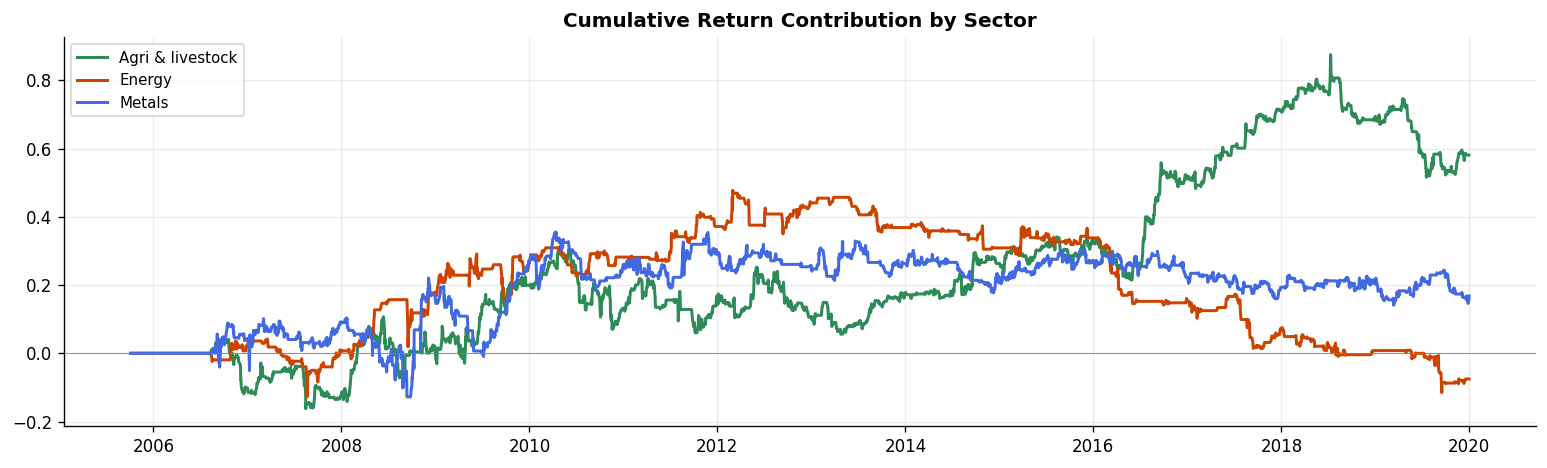

In [29]:
sc = sector_contribution(weights, returns, assets)

sc_summary = pd.DataFrame({
    'Ann. Contribution %' : (sc.mean() * 252 * 100).round(2),
    'Ann. Vol %'          : (sc.std()  * np.sqrt(252) * 100).round(2),
    'Sharpe'              : ((sc.mean() * 252) / (sc.std() * np.sqrt(252))).round(3),
})
display(sc_summary)

sector_colours = {'Agri & livestock': '#2e8b57', 'Energy': '#cc4400', 'Metals': '#4169e1'}
fig, ax = plt.subplots(figsize=(13, 4))
for col in sc.cumsum().columns:
    ax.plot(sc.cumsum().index, sc.cumsum()[col],
            color=sector_colours.get(col, 'grey'), lw=1.8, label=col)
ax.axhline(0, color='grey', lw=0.5)
ax.set_title('Cumulative Return Contribution by Sector', fontweight='bold')
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
plt.show()

In [30]:
position_summary(positions)

,Days Long,Days Short,Days Flat,% Long,% Short
LIVE CATTLE,124,216,3375,3.3,5.8
LEAN HOGS,89,282,3344,2.4,7.6
COFFEE 'C',141,439,3135,3.8,11.8
CORN,147,353,3215,4.0,9.5
COTTON NO.2,253,275,3187,6.8,7.4
SOYBEAN,219,254,3242,5.9,6.8
SUGAR #11,104,355,3256,2.8,9.6
WHEAT FUTURE,117,463,3135,3.1,12.5
BRENT CRUDE,236,145,3334,6.4,3.9
COPPER FUTURE,175,254,3286,4.7,6.8


## 4. Signal Chart

Change `COMDTY` to inspect any commodity in the dataset.

In [ ]:
COMDTY = 'BRENT CRUDE'

plot_signals(prices, {'Trend Strategy v2': {
    'filter_fast'     : FILTER_FAST,
    'filter_slow'     : FILTER_SLOW,
    'slope_lookback'  : SLOPE_LOOKBACK,
    'ema_window'      : EMA_WINDOW,
    'rsi_window'      : RSI_WINDOW,
    'rsi_level'       : RSI_LEVEL,
    'rsi_flag_window' : RSI_FLAG_WINDOW,
    'bb_window'       : BB_WINDOW,
    'bb_num_std'      : BB_NUM_STD,
    'atr_window'      : ATR_WINDOW,
    'sl_mult'         : SL_MULT,
}}, COMDTY)

## 5. Save

In [ ]:
OUT_DIR = ROOT / 'docs/task1_trend_outputs'
OUT_DIR.mkdir(parents=True, exist_ok=True)

stats.to_csv(OUT_DIR / 'performance_summary.csv')
sc_summary.to_csv(OUT_DIR / 'sector_contribution.csv')
position_summary(positions).to_csv(OUT_DIR / 'position_activity.csv')

print(f'Saved to {OUT_DIR}')

# Task 2 — Trend-Following Strategy

## 1. Layer Regime Enhancements 
  
   Adding cross asset signals to better define regimes ex. DXY growing  is bearish signals, Credit spread increase= bearish signaal , or equities goes up = bullish


## 2. Layer Entry Signal Enahncements 
  Second RSI cap for short leg vs Redesign entry with BB breakout



##  3. Slot Manager Enhancemt for drawdowns
  SL calculated with EWMA
  Parabolic SAR implementation for trailing stop